# 01 - Text embeddings & cosine similarity: the basics
Qwen3-VL-Embedding maps **text, images and video into one shared vector space**. In this notebook we stay with plain text and learn:

1. How the model turns text into a vector (instruction + text -> chat template -> last-token hidden state, L2-normalized).
2. What cosine similarity values look like for paraphrases, lexically-similar-but-different sentences, and unrelated text.
3. Whether the **8B** model separates semantics more sharply than the **2B** model.

**The two Qwen embedding families** (latest as of Oct 2026):

| family | sizes | input | notes |
|---|---|---|--- |
| Qwen3-Embedding / Qwen3-Reranker (Jun 2025) | 0.6B / 4B / 8B | text only | MTEB-multilingual #1 at release |
| **Qwen3-VL-Embedding / Qwen3-VL-Reranker (Jan 2026)** | 2B / 8B | text, image, video, mixed | one shared vector space, MRL 64-4096 dims, 32K ctx |

We use the VL family everywhere because it can embed **video** - but note that on pure-text benchmarks the text-only family is still a bit stronger.

In [1]:
import os, sys
LAB_ROOT = "/home/satishv/study/qwen3-embed-lab"
sys.path.insert(0, LAB_ROOT)
from lab_helpers import *   # wrappers, VIDEOS, VIDEO_QUERIES, embed(), inspect_entry(), plotting, ...
import numpy as np
import pandas as pd
import torch
from scipy.stats import spearmanr
print_gpu()

/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


GPU: NVIDIA GB10 (cuda)


/home/satishv/study/qwen3-embed-lab/.venv/lib/python3.12/site-packages/torch/cuda/__init__.py:283: UserWarning: 
    Found GPU0 NVIDIA GB10 which is of cuda capability 12.1.
    Minimum and Maximum cuda capability supported by this version of PyTorch is
    (8.0) - (12.0)
    
  warnings.warn(


## 1. Load the 2B embedder
On this machine (NVIDIA GB10, 128 GB unified memory) we run in bfloat16 with `sdpa` attention - `flash_attention_2` is not available on this chip.

Every input is formatted as a chat: **the instruction goes into the system message, the content into the user message**, and the embedding is the last hidden state of the final token, then L2-normalized.

In [2]:
embedder = load_embedder("2B")
n_params = sum(p.numel() for p in embedder.model.parameters())
print(f"{n_params/1e9:.2f}B params | embed dim = {embedder.model.config.text_config.hidden_size} "
      f"| defaults: fps={embedder.fps}, max_frames={embedder.max_frames}, "
      f"total_pixels={embedder.total_pixels:,}")
print("default instruction:", repr(embedder.default_instruction))

`torch_dtype` is deprecated! Use `dtype` instead!


2.13B params | embed dim = 2048 | defaults: fps=1, max_frames=64, total_pixels=7,864,320
default instruction: "Represent the user's input."


## 2. A sentence set designed to teach
- **A1/A2** and **B1/B2** are paraphrase pairs (same meaning, different words).
- **D_lex** shares many *words* with A1 (woman, plays, sun ...) but describes a different scene - the classic lexical-overlap trap.
- **C1, E1** are from unrelated topics.

In [3]:
TEXTS = {
    "A1":    "A woman plays with her golden retriever on a sunny beach.",
    "A2":    "A girl and her dog have fun on the sandy shore in bright sunshine.",
    "B1":    "Stock markets rallied after the central bank cut interest rates.",
    "B2":    "Investors cheered as equities surged when policymakers lowered borrowing costs.",
    "C1":    "Photosynthesis allows plants to convert sunlight into chemical energy.",
    "D_lex": "A woman plays a piano piece as the sun sets behind the theater.",
    "E1":    "Gravity is a fundamental force that attracts two bodies toward each other.",
}
labels = list(TEXTS)
entries = [{"text": t} for t in TEXTS.values()]      # no instruction -> default system prompt

# the wrapper's own public API
emb = embed_official(embedder, entries)
print("embeddings:", tuple(emb.shape), "| norms ~1:", emb.norm(dim=-1)[:3].tolist())

embeddings: (7, 2048) | norms ~1: [1.0, 1.0, 1.0]


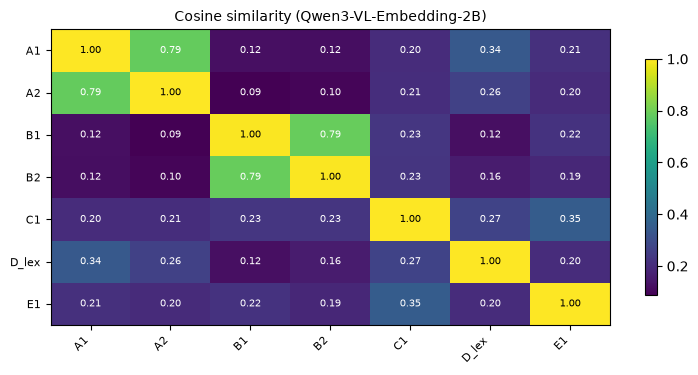

In [4]:
S = sim_matrix(emb, emb)
heatmap(S, labels, labels, "Cosine similarity (Qwen3-VL-Embedding-2B)")

In [5]:
print("nearest neighbour for each sentence (excluding itself):")
for i, lab in enumerate(labels):
    sims = S[i].copy(); sims[i] = -1
    j = int(np.argmax(sims))
    print(f"  {lab:>5} -> {labels[j]:>5}   {sims[j]:.3f}")

pairs = [("A1", "A2"), ("B1", "B2")]
def pair_stats(S):
    within = np.mean([S[labels.index(a), labels.index(b)] for a, b in pairs])
    tri = np.triu_indices(len(labels), 1)
    all_pairs = S[tri].mean()
    return within, all_pairs, within - all_pairs

w, a, sep = pair_stats(S)
print(f"\nmean paraphrase-pair similarity: {w:.3f}")
print(f"mean all-pairs similarity:      {a:.3f}")
print(f"separation (within - all):      {sep:.3f}")

nearest neighbour for each sentence (excluding itself):
     A1 ->    A2   0.785
     A2 ->    A1   0.785
     B1 ->    B2   0.789
     B2 ->    B1   0.789
     C1 ->    E1   0.352
  D_lex ->    A1   0.340
     E1 ->    C1   0.352

mean paraphrase-pair similarity: 0.787
mean all-pairs similarity:      0.257
separation (within - all):      0.530


**What to look for**
- A1-A2 and B1-B2 should be the highest off-diagonal cells: paraphrases land close together even with zero shared keywords (B1/B2).
- D_lex vs A1 should be *middle*: shared words pull them together, but different meaning keeps them apart. Embeddings are much less fooled by lexical overlap than, say, BM25.
- Cross-topic cells should be visibly darker (lower).

## 3. Same exercise with the 8B model
We free the 2B model first, then repeat with 8B. Watch two things: does 8B *sharpen* the separation, and do the two models *agree* on the ordering of all pairs?

Loading checkpoint shards: 100%|████████████████████████████████████████████████████████████████████████████| 4/4 [00:00<00:00, 182.60it/s]


8.14B params | embed dim = 4096


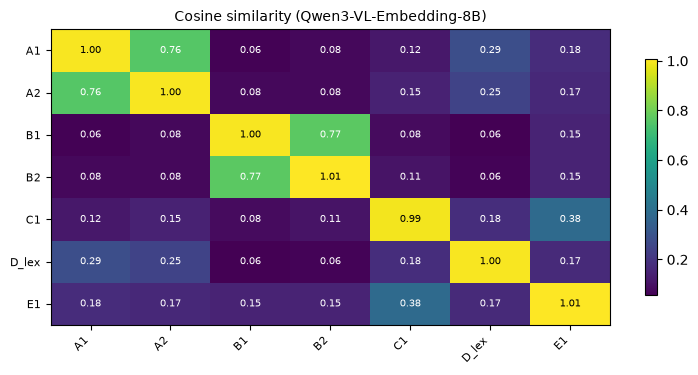

In [6]:
del embedder; torch.cuda.empty_cache()
embedder8 = load_embedder("8B")
n_params = sum(p.numel() for p in embedder8.model.parameters())
print(f"{n_params/1e9:.2f}B params | embed dim = {embedder8.model.config.text_config.hidden_size}")
emb8 = embed_official(embedder8, entries)
S8 = sim_matrix(emb8, emb8)
heatmap(S8, labels, labels, "Cosine similarity (Qwen3-VL-Embedding-8B)")

In [7]:
from scipy.stats import spearmanr
tri = np.triu_indices(len(labels), 1)
w8, a8, sep8 = pair_stats(S8)
rho, _ = spearmanr(S[tri], S8[tri])

print(f"separation:  2B = {sep:.3f}   8B = {sep8:.3f}")
print(f"Spearman agreement between 2B and 8B over all {len(tri[0])} pairs: {rho:.3f}")
print(f"(paraphrase pairs) 2B: {S[labels.index('A1'),labels.index('A2')]:.3f} | "
      f"8B: {S8[labels.index('A1'),labels.index('A2')]:.3f}")
print(f"(lexical trap A1-D_lex) 2B: {S[labels.index('A1'),labels.index('D_lex')]:.3f} | "
      f"8B: {S8[labels.index('A1'),labels.index('D_lex')]:.3f}")

separation:  2B = 0.530   8B = 0.559
Spearman agreement between 2B and 8B over all 21 pairs: 0.835
(paraphrase pairs) 2B: 0.785 | 8B: 0.758
(lexical trap A1-D_lex) 2B: 0.340 | 8B: 0.285


**Takeaways**
- Both models rank paraphrases above the lexical trap - embeddings capture *meaning*, not word overlap.
- 8B typically widens the gap between paraphrase pairs and everything else (sharper separation), and the two models agree strongly on pair ordering - a good sign that the space is stable across scales.
Next: **video** enters the same vector space (notebook 02).